# Humpback Whale Identification — Classification Baseline

**Course**: Machine Learning for Computer Vision (91266)  
**Task**: [Kaggle Whale Identification Playground](https://www.kaggle.com/competitions/whale-categorization-playground)  
**Authors**: Kristoffer Osen & Sebastian Munthe

## Overview

This notebook implements an improved image classification baseline for humpback whale
identification from fluke photographs. The task is extremely challenging:
- ~4000+ whale identities, most with only 1–5 training images
- A large "new_whale" class representing unidentified individuals
- Fine-grained visual differences (trailing-edge notches, pigmentation patterns)

We systematically address the overfitting problem observed in naive approaches through:
1. **Appropriate augmentation** (conservative, preserving identity cues)
2. **Better backbone** (EfficientNet-B5 at 456px for fine-grained detail)
3. **Freeze/unfreeze training** (preserve pretrained features, then fine-tune)
4. **Focal Loss** (handles extreme class imbalance better than cross-entropy)

All hyperparameters are controlled via a single configuration object, experiments
are indexed and checkpointed automatically, and training can resume from any point.


## Setup & Imports

In [1]:
import sys
import os
import torch
import json

# Ensure our project modules are importable
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

from config import ExperimentConfig
from experiment import ExperimentManager
from dataset import prepare_data, build_dataloaders
from models import WhaleClassifier
from losses import build_loss
from training import train
from visualization import plot_training_history
from pathlib import Path

from dataset import build_retrieval_eval_loaders
from dataset import get_eval_config_and_data
from models import build_model

# Device setup
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS")
else:
    device = torch.device("cpu")
    print("WARNING: No GPU detected. Training will be very slow.")

print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")


/root/ML4CV/models.py:65: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


GPU: NVIDIA RTX PRO 4000 Blackwell
VRAM: 25.2 GB
PyTorch: 2.10.0+cu130
Device: cuda


## Experiment Configuration


In [2]:
config = ExperimentConfig(
    experiment_name="baseline_effnetb5_cross_entropy",
    description="EfficientNet-B5 with plain Cross Entropy, no class weights, no smoothing",
    data_dir="data",
    experiments_root="experiments",

    loss_type="ce",
    use_class_weights=False,
    label_smoothing=0.0,
    batch_size=32,
    epochs=25,
    early_stopping_patience=3,
    early_stopping_metric="known_recall@1",

    freeze_backbone_epochs=3,

    scheduler="cosine",
    warmup_epochs=1,
)

print("Experiment config:")
print(config.summary())


Experiment config:
efficientnet_b5 | 456px | ce(γ=2.0) | lr=0.0001/0.001 | freeze=3ep | bs=32×2


## Data Preparation

In [3]:
data = prepare_data(config)

print(f"\nClass mapping: {data['num_classes']} known whale identities")
print(f"ID → Index examples: {dict(list(data['id_to_idx'].items())[:5])} ...")

Split (seed=42): train=7452 (4250 cls), val=1217 (405 new_whale), test=1181 (405 new_whale)

Class mapping: 4250 known whale identities
ID → Index examples: {'w_0013924': 0, 'w_001ebbc': 1, 'w_002222a': 2, 'w_002b682': 3, 'w_002dc11': 4} ...


## Train

The training procedure has two phases:

**Phase 1 — Frozen backbone** (epochs 0–2):
Only the embedding layer and classifier head are trained. This lets the new
head learn sensible weights using stable pretrained features, preventing the
backbone from being corrupted by random gradients from the untrained head.

**Phase 2 — Full fine-tuning** (epochs 3+):
The backbone is unfrozen with a 10× lower learning rate than the head.
BatchNorm layers remain in eval mode throughout (their ImageNet statistics
are more reliable than statistics from our micro-batches).

Training uses:
- **AMP** (Automatic Mixed Precision) for ~50% memory reduction
- **Gradient accumulation** (4 steps) for effective batch size of 32
- **Cosine annealing** with linear warmup
- **Gradient clipping** at norm 1.0


In [4]:
TRAINING_ENABLED = False
EXPERIMENT_ID = "20260524_230915_baseline_effnetb5_cross_entrop_a55bddfe" 

if TRAINING_ENABLED:
    # To resume a previous run, set resume_from to its experiment ID:
    manager = train(config, data, device, resume_from=EXPERIMENT_ID)
    # To start fresh:
    #manager = train(config, data, device)
else:
    print("Skipping training")
    config = ExperimentConfig.load("experiments/" + EXPERIMENT_ID + "/config.json")
    manager = ExperimentManager(config, EXPERIMENT_ID)
    

Skipping training


## Training Analysis

/root/ML4CV/visualization.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


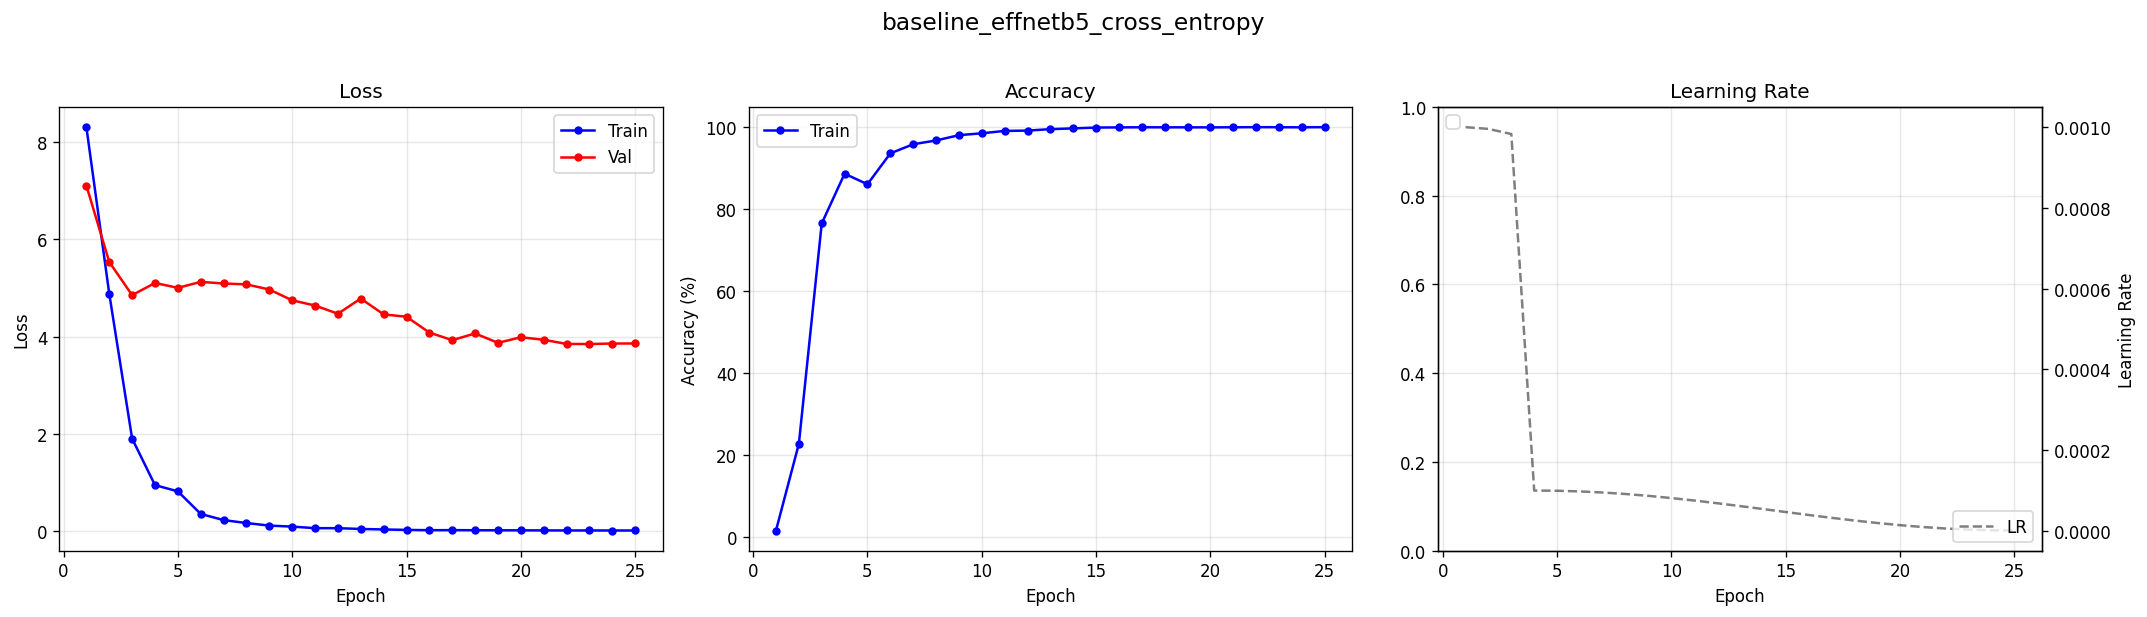

In [5]:
# Load metrics from the completed experiment
metrics_path = manager.root / "metrics.json"
with open(metrics_path, "r") as f:
    metrics = json.load(f)

plot_training_history(metrics, title=config.experiment_name)


In [6]:
print("\nFinal metrics (last epoch):")
for key in ["train_loss", "train_acc", "known_recall@1", 
            "known_recall@5", "mean_known_conf", "mean_new_whale_conf"]:
    if key in metrics:
        val = metrics[key][-1]
        if "acc" in key or "detection" in key or "recall" in key:
            print(f"  {key:<30s}: {val * 100:.2f}%")
        else:
            print(f"  {key:<30s}: {val:.4f}")



Final metrics (last epoch):
  train_loss                    : 0.0022
  train_acc                     : 99.85%
  known_recall@1                : 55.79%
  known_recall@5                : 66.38%
  mean_known_conf               : 0.7276
  mean_new_whale_conf           : 0.6595


## Evaluate Best Model


In [7]:
from final_evaluation import evaluate_base_metrics, get_classifier_predictions, get_retrieval_predictions

# Load best model
config = ExperimentConfig.load("experiments/" + EXPERIMENT_ID + "/config.json")
model = build_model(config, data["num_classes"], device)
state = torch.load("experiments/" + EXPERIMENT_ID + "/checkpoints/best.pth", map_location=device, weights_only=False)
model_state = state.get("model_state_dict", state)
model.load_state_dict(model_state)
model.eval()

# Run evaluation
#criterion = build_loss(config, data["class_counts"], device)
eval_config, data = get_eval_config_and_data()
train_loader, val_loader = build_retrieval_eval_loaders(eval_config, data)
scores, predictions, labels = get_classifier_predictions(model, val_loader, device, 5)
val_metrics = evaluate_base_metrics(scores, predictions, labels)

print("\nBest model validation metrics:")
for k, v in val_metrics.items():
    if isinstance(v, float):
        if "acc" in k or "detection" in k:
            print(f"  {k:<30s}: {v * 100:.2f}%")
        else:
            print(f"  {k:<30s}: {v:.4f}")
    else:
        print(f"  {k:<30s}: {v}")


Split (seed=42): train=7452 (4250 cls), val=1217 (405 new_whale), test=1181 (405 new_whale)


Extracting Classifier Preds:   0%|          | 0/51 [00:00<?, ?it/s]


Best model validation metrics:
  known_recall@1                : 0.5579
  known_recall@5                : 0.6687
  mean_known_conf               : 0.7239
  mean_new_whale_conf           : 0.6618


## Embedding Quality

### t-SNE Visualization


  Extracting embeddings:   0%|          | 0/51 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/311 [00:00<?, ?it/s]

t-SNE: 224 points, 10 classes (min 5/class)


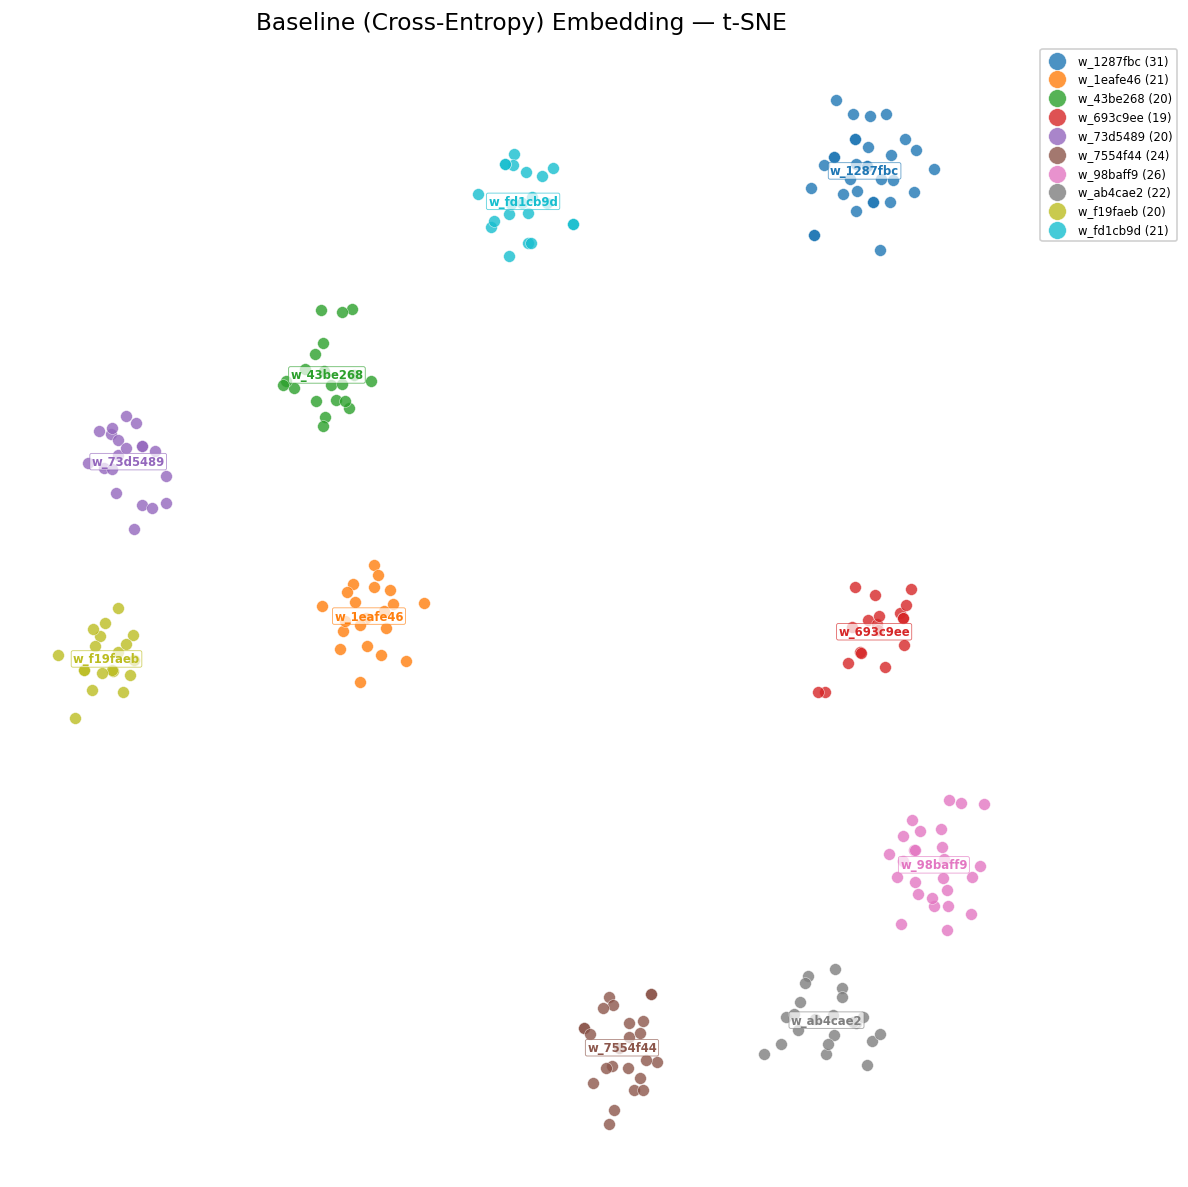

  Perplexity used: 28 | KL divergence: 0.17


In [8]:
# ── Usage ────────────────────────────────────────────────────────────────
# Combine train + val loaders to get enough points per class for visible clusters.
# This is purely for visualization — evaluation metrics stay on val only.
from visualization import plot_embedding_tsne

if model is not None:
    plot_embedding_tsne(
        model, val_loader, data, device,
        title="Baseline (Cross-Entropy) Embedding — t-SNE",
        top_k_classes=10,
        min_samples_per_class=5,
        combine_loaders=[train_loader],
    )